# LDA with gensim and spaCy

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
!pip install -qq gensim
!pip install pyLDAvis -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 7.6 MB/s eta 0:00:00


In [23]:
import numpy as np
import pandas as pd

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

#spacy
import spacy
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Preparing the Data

In [6]:
pd.set_option('display.max_colwidth', None)
headlines = pd.read_csv('/content/abcnews-date-text.csv')
headlines

,publish_date,headline_text
0,20030219,aba decides against community broadcasting licence
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
720498,20120829,tourist guilty of security guard assault
720499,20120829,traffic chaos after egg truck flip
720500,20120829,transfield shares slump as ceo leaves
720501,20120829,trickle of money for flood mitigation


In [7]:
headlines['year'] = headlines['publish_date'] // 10000
headlines['month'] = (headlines['publish_date'] // 100) % 100
headlines['months_since_2003'] = (headlines['year'] - 2003) * 12 + headlines['month']
headlines = headlines.drop(['year', 'month'], axis=1)
headlines

,publish_date,headline_text,months_since_2003
0,20030219,aba decides against community broadcasting licence,2
1,20030219,act fire witnesses must be aware of defamation,2
2,20030219,a g calls for infrastructure protection summit,2
3,20030219,air nz staff in aust strike for pay rise,2
4,20030219,air nz strike to affect australian travellers,2
...,...,...,...
720498,20120829,tourist guilty of security guard assault,116
720499,20120829,traffic chaos after egg truck flip,116
720500,20120829,transfield shares slump as ceo leaves,116
720501,20120829,trickle of money for flood mitigation,116


In [8]:
X_train, X_test = train_test_split(headlines, train_size=100000, random_state=111, stratify=headlines['months_since_2003'])
X_train = X_train.reset_index()
X_train = X_train.drop('index', axis=1)
X_train

,publish_date,headline_text,months_since_2003
0,20090602,no timetable to scrap nuclear dump,78
1,20071010,coliban water announces changes,58
2,20110510,press call kane cornes,101
3,20061231,big turn out for nye celebrations,48
4,20040923,probe launched into benalla derailment,21
...,...,...,...
99995,20030223,missile issue can be resolved with less pressure,2
99996,20120720,page chasing another olympic gold,115
99997,20100209,govt urged to review work death prosecutions,86
99998,20050906,fit again cats ready for swans,33


In [14]:
test1, test2 = train_test_split(X_train, train_size=10000, random_state=111, stratify=X_train['months_since_2003'])
test1

,publish_date,headline_text,months_since_2003
24310,20100128,council to re establish sister city ties,85
41482,20120118,kohler report,109
9331,20090312,indonesian mud victims demand compensation,75
23336,20050915,world leaders call for ban on incitement to,33
51852,20110722,council accused of indigenous discrimination,103
...,...,...,...
3113,20060227,community grief stricken after five people die in,38
17096,20031224,police probe mildura teen rape,12
5095,20081018,hayes loses zagreb from caulfield cup,70
33935,20050506,mourners gather for rivkin funeral,29


## Text Preprocessing

In [29]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    texts_out = []

    for doc in nlp.pipe(texts, batch_size=2000, n_process=-1):

        new_text = [t.lemma_ for t in doc if t.pos_ in allowed_postags
                    and not t.is_stop and len(t.lemma_) > 2]
        if new_text:
            texts_out.append(new_text)

    return texts_out

In [30]:
data_tokens = lemmatization(test1['headline_text'])

## Model training and k-fold cross-validation

Testing K=3...
Testing K=4...
Testing K=5...
Testing K=6...
Testing K=7...
Testing K=10...


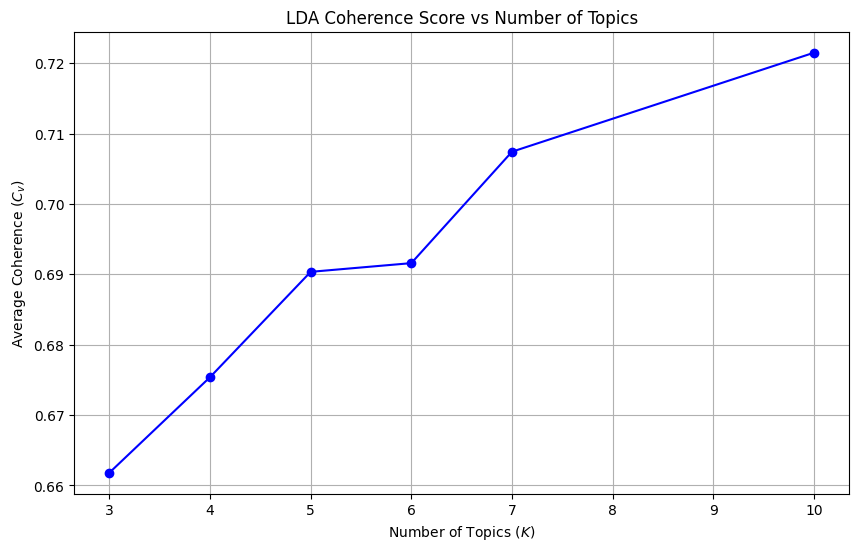

In [38]:
topic_range = [3, 4, 5, 6, 7, 10]
mean_coherence_values = []

for k in topic_range:
    print(f"Testing K={k}...")
    kf = KFold(n_splits=5, shuffle=True, random_state=111)
    fold_scores = []

    for train_index, test_index in kf.split(data_tokens):
        train_texts = [data_tokens[i] for i in train_index]
        test_texts = [data_tokens[i] for i in test_index]

        id2word = corpora.Dictionary(train_texts)
        id2word.filter_extremes(no_below=5, no_above=0.5)
        train_corpus = [id2word.doc2bow(text) for text in train_texts]

        lda = gensim.models.LdaModel(
            corpus=train_corpus,
            id2word=id2word,
            num_topics=k,
            random_state = 111,
            passes=5,
            alpha='auto',
            eta='auto'
        )

        cm = CoherenceModel(model=lda, texts=test_texts, dictionary=id2word, coherence='c_v')
        fold_scores.append(cm.get_coherence())

    mean_coherence_values.append(np.mean(fold_scores))

## Visualizing the coherence scores

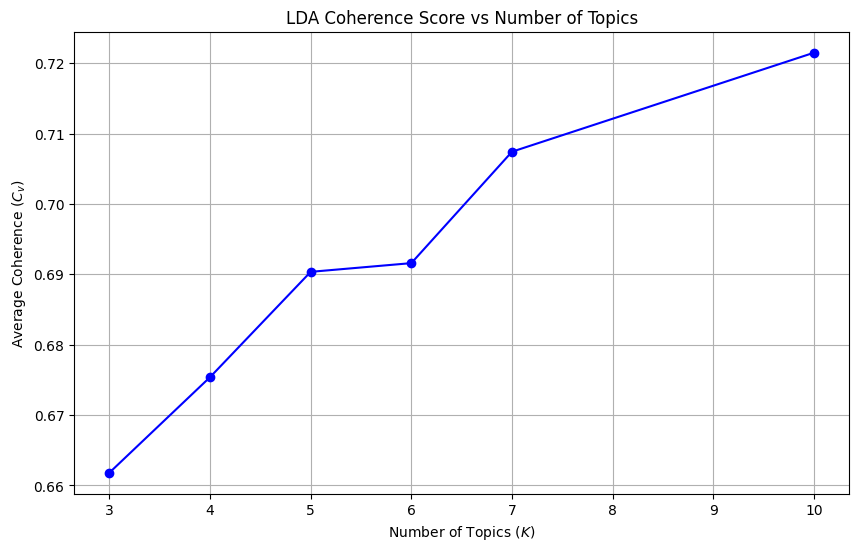

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(topic_range, mean_coherence_values, marker='o', color='b', linestyle='-')
plt.title("LDA Coherence Score vs Number of Topics")
plt.xlabel("Number of Topics ($K$)")
plt.ylabel("Average Coherence ($C_v$)")
plt.grid(True)
plt.show()

In [10]:
# bigrams_phrases = gensim.models.Phrases(lemmatized_texts, min_count=5, threshold=50)
# trigrams_phrases = gensim.models.Phrases(bigrams_phrases[lemmatized_texts], threshold=50)

# bigram = gensim.models.phrases.Phraser(bigrams_phrases)
# trigram = gensim.models.phrases.Phraser(trigrams_phrases)

# def make_bigrams(texts):
#   return [bigram[doc] for doc in texts]

# def make_trigrams(texts):
#   return [trigram[bigram[doc]] for doc in texts]

# data_bigrams = make_bigrams(lemmatized_texts)
# data_bigrams_trigrams = make_trigrams(data_bigrams)

# print(data_bigrams_trigrams)

In [ ]:
lda_display = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
pyLDAvis.display(lda_display)